In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [14]:
# Load dataset
df = pd.read_csv("titanic.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [15]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (418, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [16]:
# Define target variable
target_variable = "Survived"
print("Target Variable:", target_variable)

Target Variable: Survived


# Task 1: Identify Data Quality Issues

In this step, we inspect the dataset to identify possible data quality issues such as:
- Missing values
- Duplicate rows
- Data types
- Irrelevant columns
- Potential outliers

In [17]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (418, 12)

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Duplicate Rows: 0


In [18]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


### Identified Data Quality Issues

After inspecting the Titanic dataset, the following issues were identified:

1. **Missing values** were found in some columns such as `Age`, `Cabin`, and `Embarked`.
2. **Duplicate rows** were checked to determine whether repeated records exist.
3. Some columns such as `Name`, `Ticket`, and `Cabin` may not be useful for numerical preprocessing.
4. Numerical features such as `Fare` and `Age` may contain outliers.

These issues must be handled before applying preprocessing techniques.

In [19]:
# Drop columns with too many missing values or low preprocessing value
df_clean = df.copy()

# Drop Cabin because it has too many missing values
if 'Cabin' in df_clean.columns:
    df_clean.drop(columns=['Cabin'], inplace=True)

# Drop irrelevant text columns
for col in ['Name', 'Ticket', 'PassengerId']:
    if col in df_clean.columns:
        df_clean.drop(columns=[col], inplace=True)

df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.5,0,0,7.8292,Q
1,1,3,female,47.0,1,0,7.0000,S
2,0,2,male,62.0,0,0,9.6875,Q
3,0,3,male,27.0,0,0,8.6625,S
4,1,3,female,22.0,1,1,12.2875,S


### Explanation

The following columns were removed:

- `Cabin`: contains too many missing values.
- `Name`, `Ticket`, and `PassengerId`: not useful for numerical preprocessing tasks such as normalization and PCA.

This helps simplify the dataset and focus on relevant features.

# Task 2: Handle Missing Values

A missing value strategy is applied to handle incomplete records.

### Strategy Used
- **Median imputation** for numerical features
- **Mode imputation** for categorical features

### Why?
The median is more robust to outliers, while the mode is suitable for categorical variables.

In [20]:
# Check missing values before handling
print("Missing before:")
print(df_clean.isnull().sum())

Missing before:
Survived     0
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64


In [21]:
# Separate numerical and categorical columns
numerical_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Columns: ['Sex', 'Embarked']


In [22]:
# Fill numerical missing values with median
for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical missing values with mode
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing after:")
print(df_clean.isnull().sum())

Missing after:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### Explanation

Missing values were handled as follows:

- **Median imputation** was used for numerical features such as `Age`.
- **Mode imputation** was used for categorical features such as `Embarked`.

This approach preserves the dataset while ensuring no missing values remain.

# Task 3: Detect and Handle Outliers Using IQR

Outliers are detected using the Interquartile Range (IQR):

- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside this range are considered outliers.

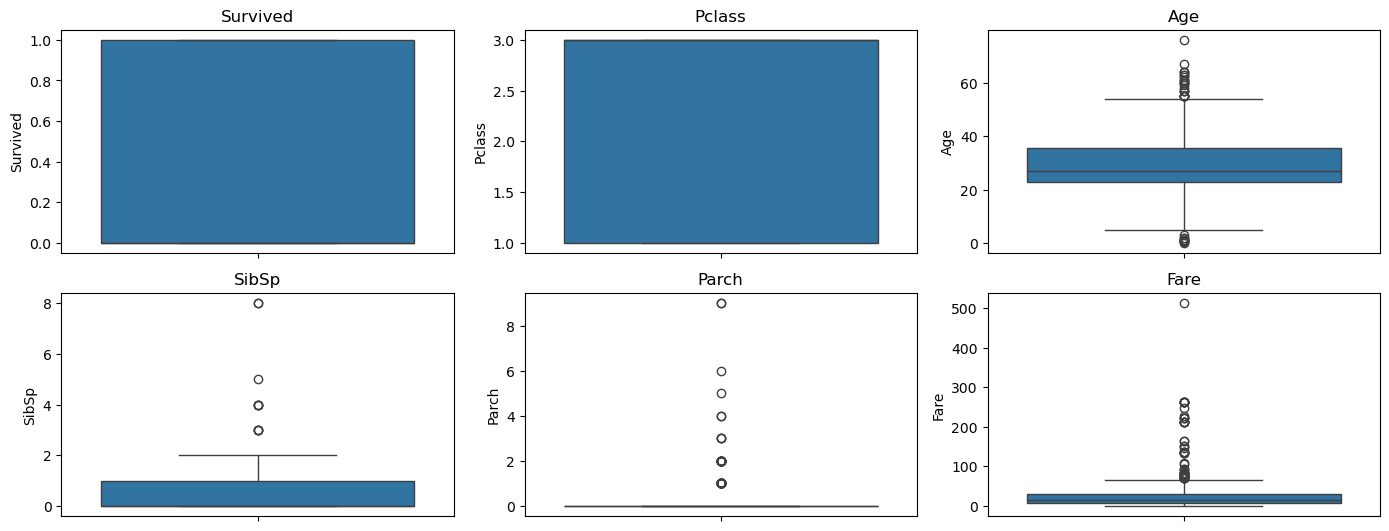

In [23]:
# Boxplots before handling outliers
plt.figure(figsize=(14,8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot((len(numerical_cols)//3)+1, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [24]:
# Handle outliers using capping
df_outlier = df_clean.copy()

for col in numerical_cols:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_outlier[col] = np.where(df_outlier[col] < lower, lower, df_outlier[col])
    df_outlier[col] = np.where(df_outlier[col] > upper, upper, df_outlier[col])

print("Outlier handling completed.")

Outlier handling completed.


### Explanation

Outliers were handled using **capping** instead of removing rows.

This method was chosen because:
- It preserves the dataset size.
- It reduces the influence of extreme values.
- It avoids unnecessary data loss.

# Task 4: Normalize Numerical Features

Two normalization techniques were applied:

1. **Min-Max Scaling**
2. **Z-score Standardization**

In [25]:
# Min-Max Scaling
minmax = MinMaxScaler()
df_minmax = df_outlier.copy()
df_minmax[numerical_cols] = minmax.fit_transform(df_minmax[numerical_cols])

# Z-score Standardization
zscore = StandardScaler()
df_zscore = df_outlier.copy()
df_zscore[numerical_cols] = zscore.fit_transform(df_zscore[numerical_cols])

print("Min-Max Sample:")
display(df_minmax.head())

print("\nZ-score Sample:")
display(df_zscore.head())

Min-Max Sample:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,1.0,male,0.600490,0.0,0.0,0.117140,Q
1,1.0,1.0,female,0.845588,0.4,0.0,0.104734,S
2,0.0,0.5,male,1.000000,0.0,0.0,0.144944,Q
3,0.0,1.0,male,0.453431,0.0,0.0,0.129608,S
4,1.0,1.0,female,0.355392,0.4,0.0,0.183846,S



Z-score Sample:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,-0.755929,0.873482,male,0.437674,-0.622272,0.0,-0.794366,Q
1,1.322876,0.873482,female,1.501076,0.949387,0.0,-0.833539,S
2,-0.755929,-0.315819,male,2.171019,-0.622272,0.0,-0.706576,Q
3,-0.755929,0.873482,male,-0.200367,-0.622272,0.0,-0.754999,S
4,1.322876,0.873482,female,-0.625728,0.949387,0.0,-0.583747,S


### Explanation

- **Min-Max Scaling** transforms numerical values into the range [0,1].
- **Z-score Standardization** transforms numerical values so that they have a mean of 0 and a standard deviation of 1.

Both methods were applied to compare their effects on the numerical features.

# Task 5: PCA Based on Correlation

PCA is applied only if numerical features show sufficient correlation.

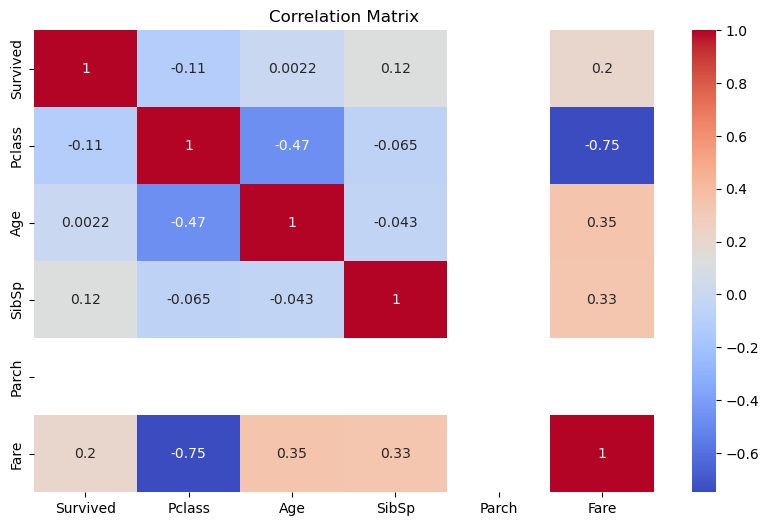

In [26]:
#  PCA Based on Correlation

corr = df_outlier[numerical_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [27]:
df_outlier['Parch'].value_counts()

Parch
0.0    418
Name: count, dtype: int64

Correlation detected → Applying PCA
Explained Variance Ratio:
[0.43082528 0.23304567 0.17782025 0.11884389 0.03946491 0.        ]


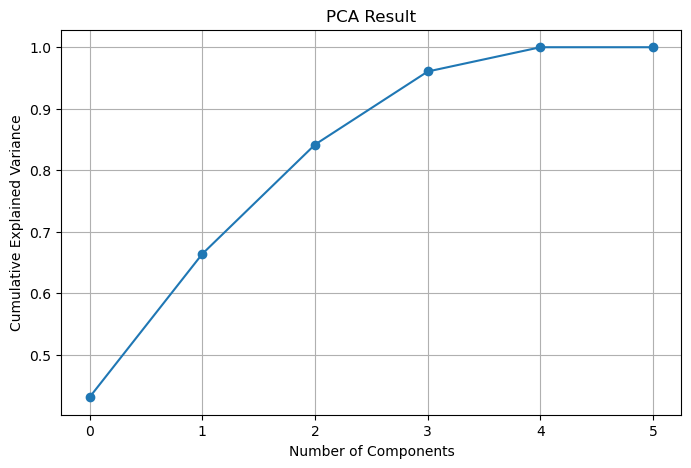

In [28]:
corr_check = corr.abs()
np.fill_diagonal(corr_check.values, 0)

if (corr_check > 0.5).any().any():
    print("Correlation detected → Applying PCA")

    pca = PCA()
    pca_data = pca.fit_transform(df_zscore[numerical_cols])

    explained_variance = pca.explained_variance_ratio_
    print("Explained Variance Ratio:")
    print(explained_variance)

    plt.figure(figsize=(8,5))
    plt.plot(np.cumsum(explained_variance), marker='o')
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Result")
    plt.grid(True)
    plt.show()

else:
    print("No strong correlation detected → PCA not applied")

### Explanation

PCA was applied only after confirming that numerical features showed correlation.

This follows the assignment requirement because PCA is useful when variables share overlapping information.